# Regression Track — Crop Yield Dataset


## 1. Imports & Setup

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score
)

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    PolynomialFeatures
)

from sklearn.pipeline import Pipeline

from sklearn.compose import ColumnTransformer

# Regression algorithms
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.svm import SVR

from sklearn.neighbors import KNeighborsRegressor

# Evaluation metrics
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

from sklearn import set_config

# Visualization settings
sns.set_style("whitegrid")
sns.set_palette("colorblind")

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Pandas display settings
pd.set_option("display.max_columns", None)

# Keep estimator output as plain text
set_config(display="text")

### Section A — Dataset & EDA
### A1. Dataset Loading & Audit

In [3]:
df = pd.read_csv("Crop Yeild Data.csv")
df.columns = df.columns.str.strip()

# Clean stray whitespace inside string columns (e.g. 'Kharif     ' -> 'Kharif')
for c in df.select_dtypes(include="object").columns:
    df[c] = df[c].str.strip()

df

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Avg_Temperature,Max_Temperature,Min_Temperature
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796,23.692,33.435,14.779
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710,23.692,33.435,14.779
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238,23.692,33.435,14.779
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.052,23.692,33.435,14.779
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.421,23.692,33.435,14.779
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19684,Small millets,1998,Kharif,Nagaland,4000.0,2000,1498.0,395200.00,1160.00,0.500,20.292,29.860,12.067
19685,Wheat,1998,Rabi,Nagaland,1000.0,3000,1498.0,98800.00,290.00,3.000,20.292,29.860,12.067
19686,Maize,1997,Kharif,Jammu and Kashmir,310883.0,440900,1356.2,29586735.11,96373.73,1.285,-3.143,9.582,-15.017
19687,Rice,1997,Kharif,Jammu and Kashmir,275746.0,5488,1356.2,26242746.82,85481.26,0.017,-3.143,9.582,-15.017


In [4]:
print("Shape:", df.shape)

print("\n=== Data types ===")
print(df.dtypes)

print("\n=== Missing value counts ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
print(missing_summary[missing_summary["Missing Count"] > 0].sort_values("Missing %", ascending=False))
if missing.sum() == 0:
    print("(no missing values in any column)")

print("\n=== Target (Yield) distribution ===")
print(df["Yield"].describe())

print("\n=== Season value counts ===")
print(df["Season"].value_counts())

print("\n=== Crop / State cardinality ===")
print("Unique Crops:", df["Crop"].nunique())
print("Unique States:", df["State"].nunique())

Shape: (19689, 13)

=== Data types ===
Crop                object
Crop_Year            int64
Season              object
State               object
Area               float64
Production           int64
Annual_Rainfall    float64
Fertilizer         float64
Pesticide          float64
Yield              float64
Avg_Temperature    float64
Max_Temperature    float64
Min_Temperature    float64
dtype: object

=== Missing value counts ===
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []
(no missing values in any column)

=== Target (Yield) distribution ===
count    19689.000000
mean        79.954011
std        878.306194
min          0.000000
25%          0.600000
50%          1.030000
75%          2.389000
max      21105.000000
Name: Yield, dtype: float64

=== Season value counts ===
Season
Kharif        8232
Rabi          5742
Whole Year    3717
Summer        1195
Autumn         414
Winter         389
Name: count, dtype: int64

=== Crop / State cardinality ===
Unique Crops: 55
Un

### A2. EDA Visualisations

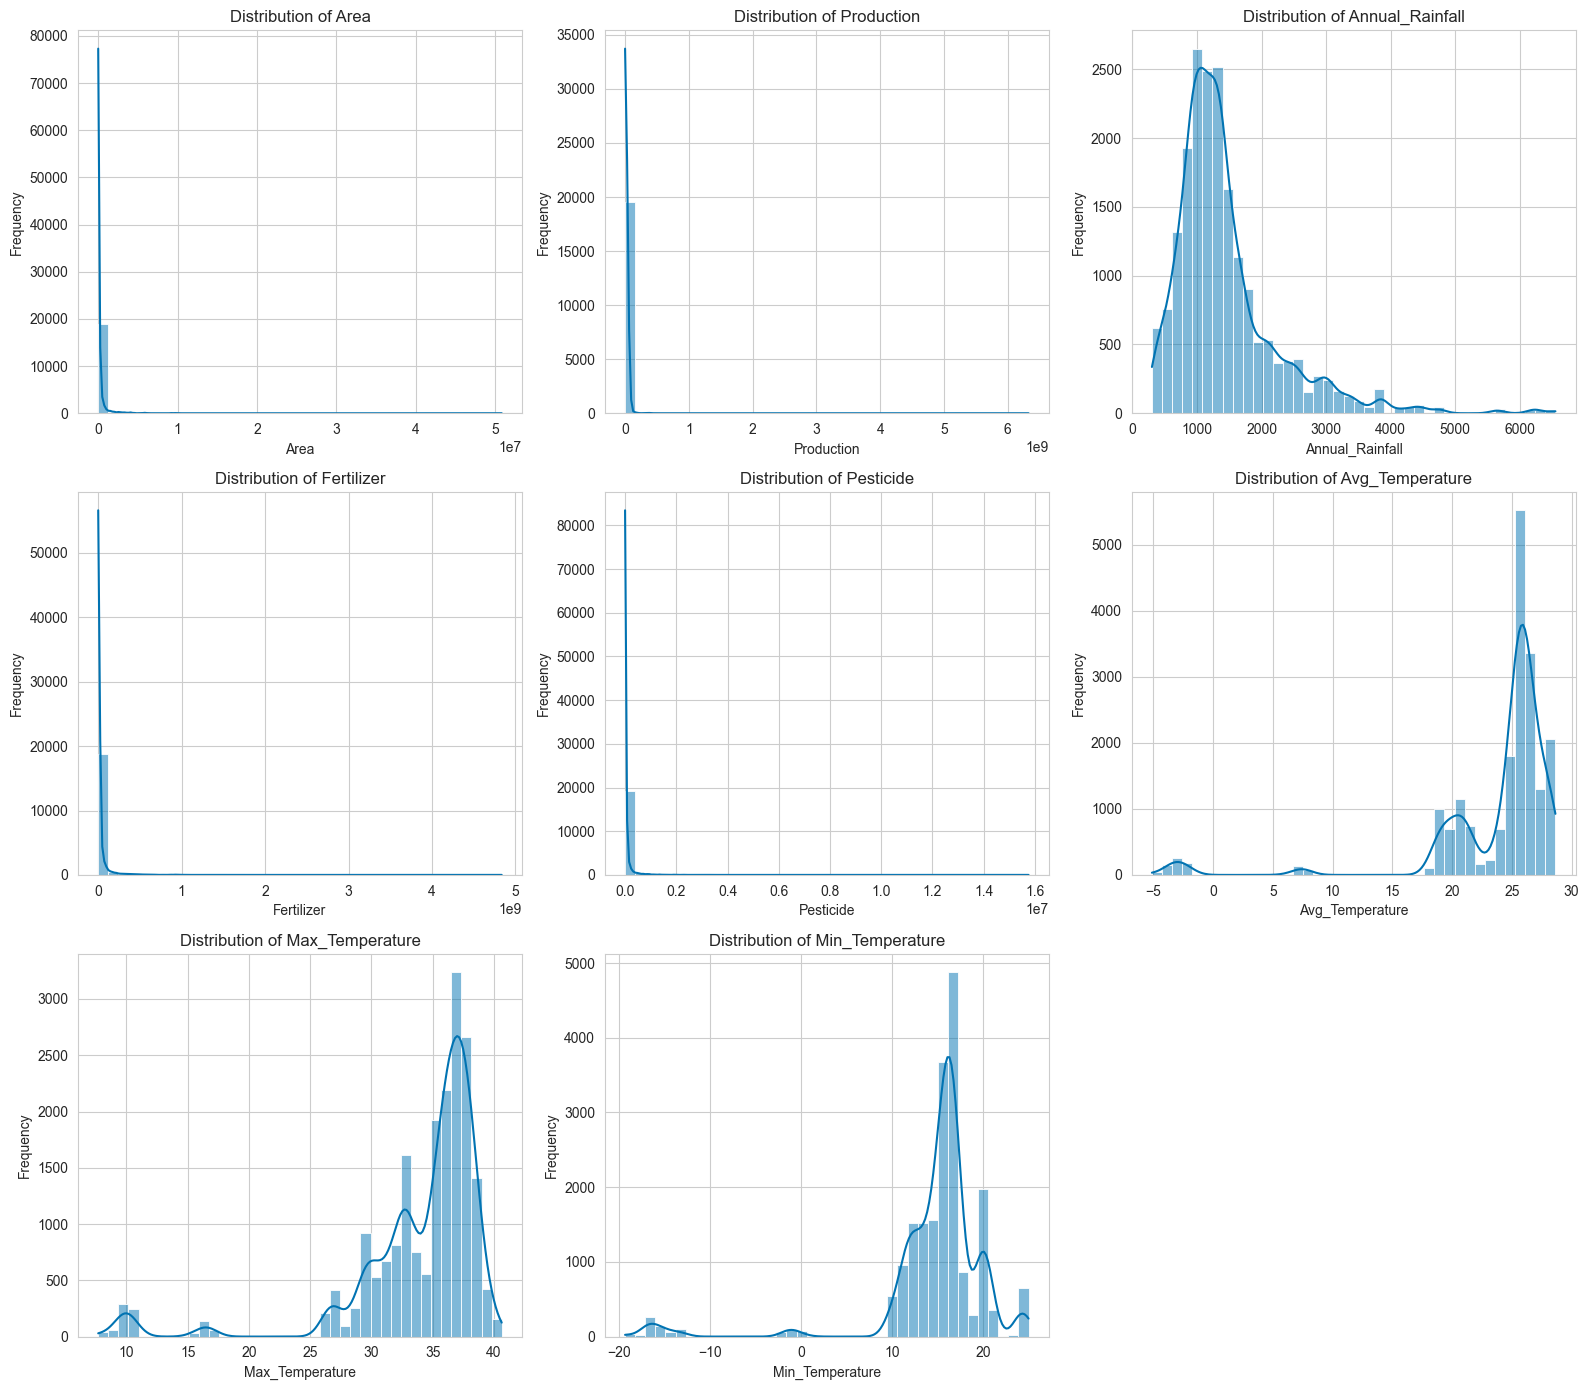

In [5]:
numeric_cols = ["Area", "Production", "Annual_Rainfall", "Fertilizer", "Pesticide",
                "Avg_Temperature", "Max_Temperature", "Min_Temperature"]

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax, bins=40)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
axes.flatten()[-1].axis("off")
plt.tight_layout()
plt.savefig("feature_distributions.png", bbox_inches="tight", dpi=100)
plt.show()

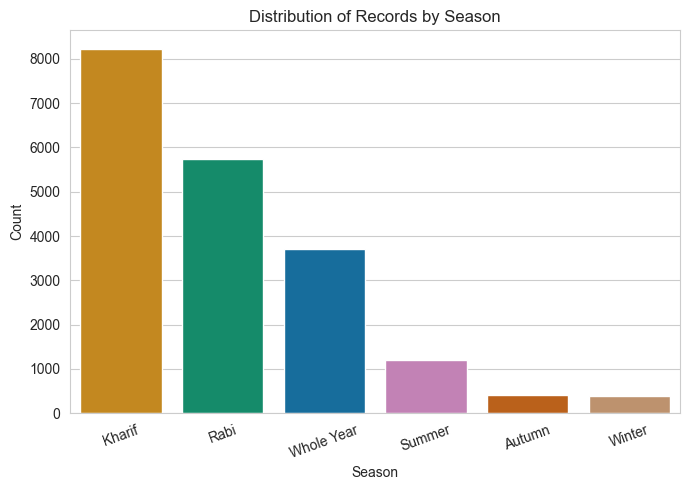

In [6]:
# Categorical distribution: Season
plt.figure(figsize=(7, 5))
season_order = df["Season"].value_counts().index
sns.countplot(data=df, x="Season", order=season_order, hue="Season",
              palette="colorblind", legend=False)
plt.title("Distribution of Records by Season")
plt.xlabel("Season")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("season_countplot.png", bbox_inches="tight", dpi=100)
plt.show()

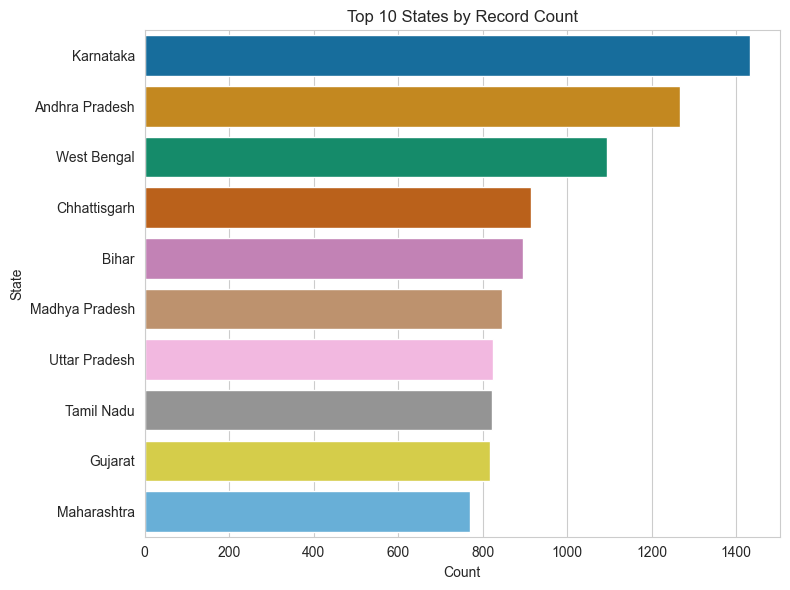

In [7]:
# Top 10 States by number of records
plt.figure(figsize=(8, 6))
top_states = df["State"].value_counts().head(10)
sns.barplot(x=top_states.values, y=top_states.index, hue=top_states.index,
            palette="colorblind", legend=False)
plt.title("Top 10 States by Record Count")
plt.xlabel("Count")
plt.ylabel("State")
plt.tight_layout()
plt.savefig("top_states.png", bbox_inches="tight", dpi=100)
plt.show()

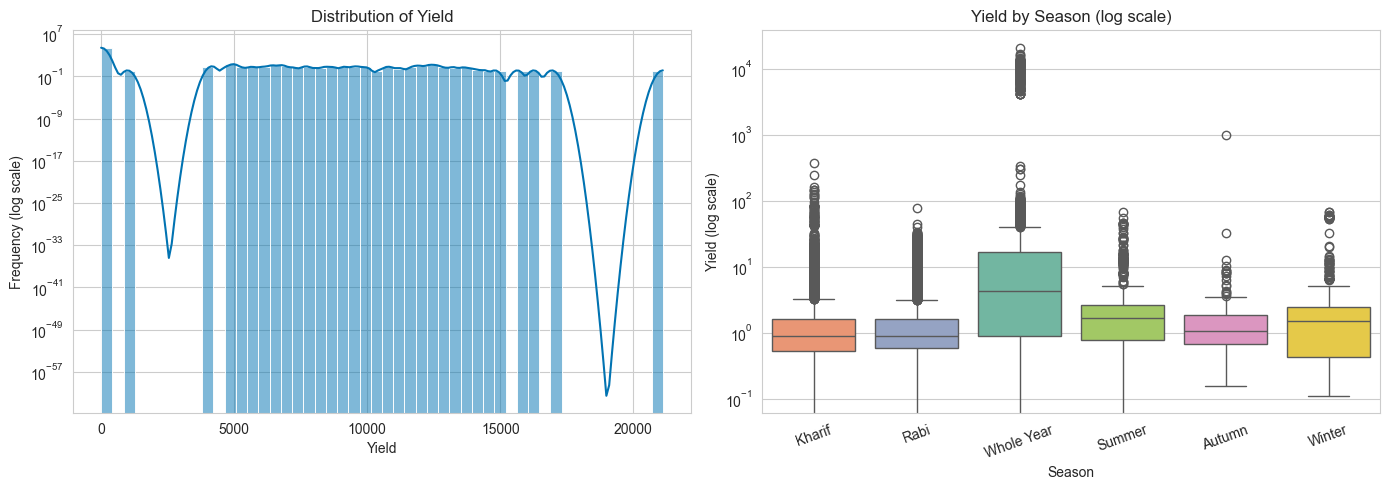

In [8]:
# Target distribution + Yield by Season
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["Yield"], kde=True, ax=axes[0], bins=50)
axes[0].set_title("Distribution of Yield")
axes[0].set_xlabel("Yield")
axes[0].set_yscale("log")
axes[0].set_ylabel("Frequency (log scale)")

sns.boxplot(data=df, x="Season", y="Yield", order=season_order, hue="Season",
            palette="Set2", legend=False, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Yield by Season (log scale)")
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Yield (log scale)")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("target_distribution1.png", bbox_inches="tight", dpi=100)
plt.show()

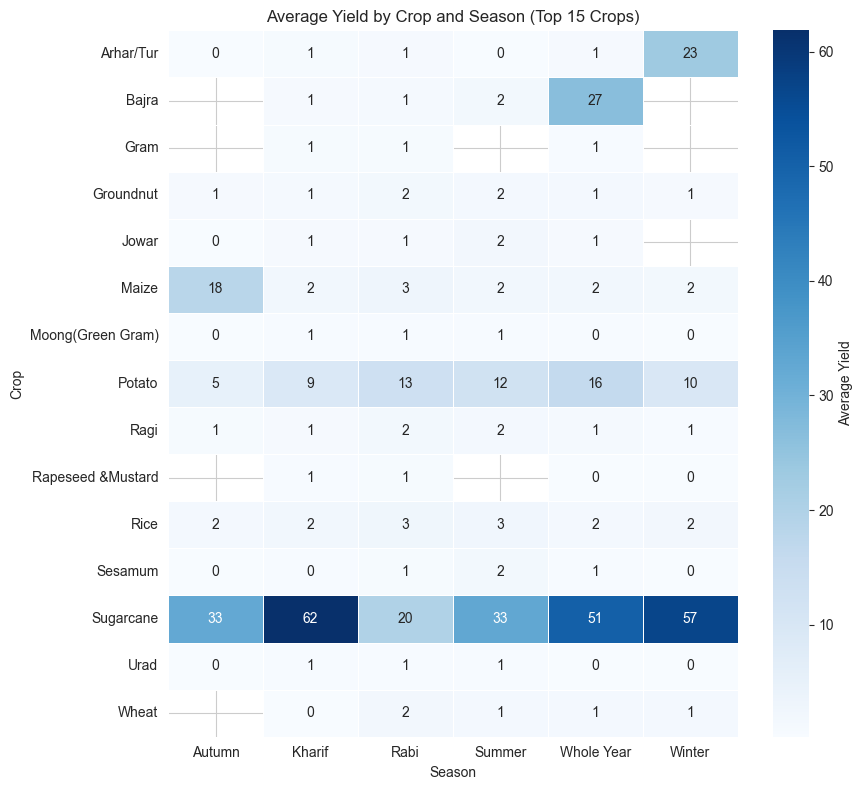

In [9]:
# Heatmap: Average Yield by Crop and Season (Blues colormap)
top_crops = df["Crop"].value_counts().head(15).index
pivot_crop_season = df[df["Crop"].isin(top_crops)].pivot_table(
    values="Yield", index="Crop", columns="Season", aggfunc="mean"
)

plt.figure(figsize=(9, 8))
sns.heatmap(pivot_crop_season, annot=True, fmt=".0f", cmap="Blues", linewidths=0.5,
            cbar_kws={"label": "Average Yield"})
plt.title("Average Yield by Crop and Season (Top 15 Crops)")
plt.xlabel("Season")
plt.ylabel("Crop")
plt.tight_layout()
plt.savefig("crop_season_yield_heatmap.png", bbox_inches="tight", dpi=100)
plt.show()

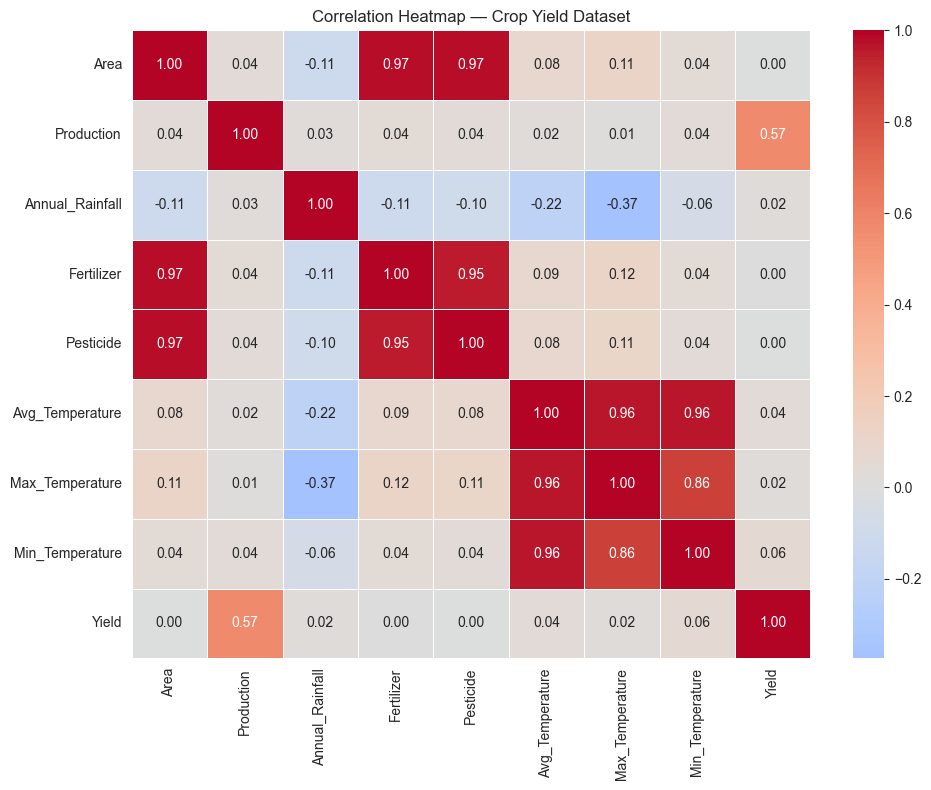

In [10]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
corr_cols = numeric_cols + ["Yield"]
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, linewidths=0.5, fmt=".2f")
plt.title("Correlation Heatmap — Crop Yield Dataset")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", bbox_inches="tight", dpi=100)
plt.show()

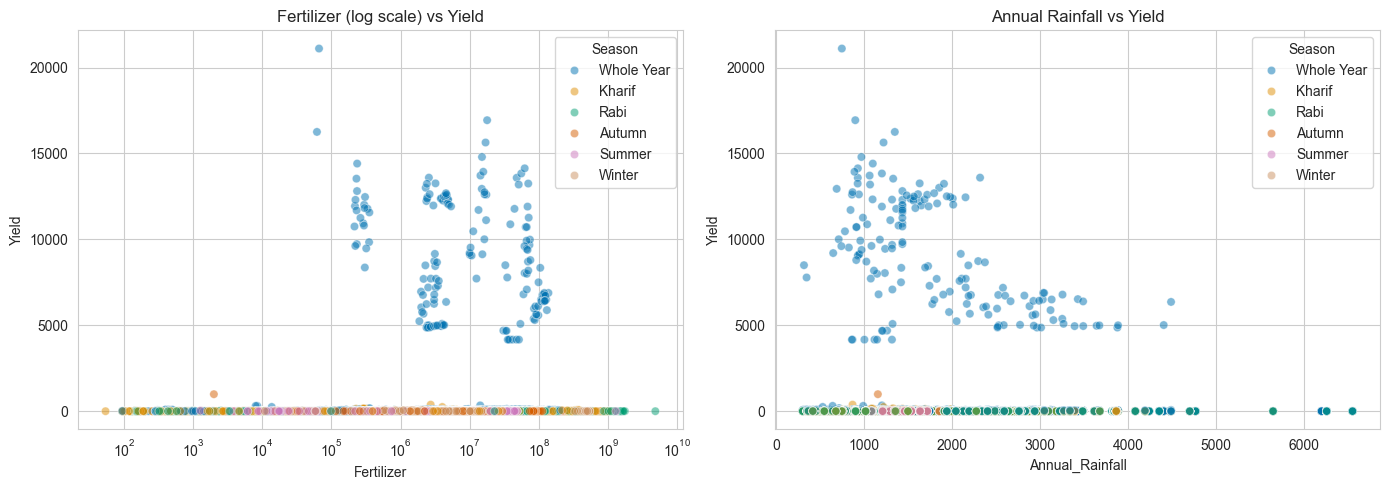

In [11]:
# Scatter plots: feature vs target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x="Fertilizer", y="Yield", hue="Season", alpha=0.5, ax=axes[0])
axes[0].set_xscale("log")
axes[0].set_title("Fertilizer (log scale) vs Yield")

sns.scatterplot(data=df, x="Annual_Rainfall", y="Yield", hue="Season", alpha=0.5, ax=axes[1])
axes[1].set_title("Annual Rainfall vs Yield")

plt.tight_layout()
plt.savefig("scatter_feature_target.png", bbox_inches="tight", dpi=100)
plt.show()

### A3. Insight commentary

**Observation:**

- **Target distribution**: `Yield` is strongly right-skewed — most crop-season-state records cluster
  at low yield values, with a long tail from a handful of high-yield crops measured in different units.
- **Feature distributions**: `Area`, `Production`, `Fertilizer`, and `Pesticide` are all heavily
  right-skewed, dominated by a small number of large-farm / high-volume records.
- **Season distribution**: Kharif and Rabi dominate the record count; Autumn and Winter are rare,
  so a stratified split on `Season` is used in Section B to keep this balance consistent across
  train/test.
- **Feature vs target**: No single numeric feature shows a strong linear trend against `Yield` on
  its own — yield is driven more by *which* crop/season/state a record belongs to than by any one
  numeric driver, which is why the categorical features are retained (not dropped) for modelling.


### Section B — Preprocessing & Feature Engineering

In [12]:
data1 = df.copy()
display(data1.isnull().sum())

# Remove duplicates
data1 = data1.drop_duplicates().reset_index(drop=True)

# Remove rows where target is missing (none present, kept for robustness)
data1 = data1.dropna(subset=["Yield"]).reset_index(drop=True)
print("Final shape after target cleaning:", data1.shape)

Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
Avg_Temperature    0
Max_Temperature    0
Min_Temperature    0
dtype: int64

Final shape after target cleaning: (19689, 13)


In [13]:
# Split feature and target
X = data1.drop(columns=["Yield", "Production"])
y = data1["Yield"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=X["Season"]
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (15751, 11)  Test shape: (3938, 11)


In [15]:
num_cols = X_train.select_dtypes(include="number").columns
cat_cols = X_train.select_dtypes(include="object").columns

num_imputer = SimpleImputer(strategy="median")
X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = num_imputer.transform(X_test[num_cols])

cat_imputer = SimpleImputer(strategy="most_frequent")
X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

print("Remaining missing values — train:", X_train.isnull().sum().sum(),
      " test:", X_test.isnull().sum().sum())

Remaining missing values — train: 0  test: 0


In [16]:
Q1 = X_train[num_cols].quantile(0.25)
Q3 = X_train[num_cols].quantile(0.75)
IQR = Q3 - Q1

outliers = ((X_train[num_cols] < (Q1 - 1.5 * IQR)) | (X_train[num_cols] > (Q3 + 1.5 * IQR))).sum()
outliers

Crop_Year             0
Area               2445
Annual_Rainfall    1205
Fertilizer         2457
Pesticide          2421
Avg_Temperature    1475
Max_Temperature     675
Min_Temperature    1217
dtype: int64

In [17]:
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

X_train[num_cols] = X_train[num_cols].clip(lower, upper, axis=1)
X_test[num_cols] = X_test[num_cols].clip(lower, upper, axis=1)

In [18]:
cat_cols = X_train.select_dtypes(include="object").columns

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_train_encoded = encoder.fit_transform(X_train[cat_cols])
X_test_encoded = encoder.transform(X_test[cat_cols])

encoded_cols = encoder.get_feature_names_out(cat_cols)

X_train_encoded = pd.DataFrame(X_train_encoded, columns=encoded_cols, index=X_train.index)
X_test_encoded = pd.DataFrame(X_test_encoded, columns=encoded_cols, index=X_test.index)

# Remove original categorical columns, add encoded columns
X_train = pd.concat([X_train.drop(columns=cat_cols), X_train_encoded], axis=1)
X_test = pd.concat([X_test.drop(columns=cat_cols), X_test_encoded], axis=1)

print("Feature count after one-hot encoding:", X_train.shape[1])

Feature count after one-hot encoding: 99


In [19]:
# Feature Engineering
X_train["Fertilizer_per_Area"] = X_train["Fertilizer"] / X_train["Area"].replace(0, np.nan)
X_test["Fertilizer_per_Area"] = X_test["Fertilizer"] / X_test["Area"].replace(0, np.nan)

X_train["Pesticide_per_Area"] = X_train["Pesticide"] / X_train["Area"].replace(0, np.nan)
X_test["Pesticide_per_Area"] = X_test["Pesticide"] / X_test["Area"].replace(0, np.nan)

# A handful of ratios can be NaN/inf where Area was 0 before capping; fill with the train median
for c in ["Fertilizer_per_Area", "Pesticide_per_Area"]:
    med = X_train[c].replace([np.inf, -np.inf], np.nan).median()
    X_train[c] = X_train[c].replace([np.inf, -np.inf], np.nan).fillna(med)
    X_test[c] = X_test[c].replace([np.inf, -np.inf], np.nan).fillna(med)

In [20]:
X_train_columns = X_train.columns
X_test_columns = X_test.columns

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = pd.DataFrame(X_train, columns=X_train_columns)
X_test = pd.DataFrame(X_test, columns=X_test_columns)

print("Final training feature matrix:", X_train.shape)
X_train.head()

Final training feature matrix: (15751, 101)


,Crop_Year,Area,Annual_Rainfall,Fertilizer,Pesticide,Avg_Temperature,Max_Temperature,Min_Temperature,Crop_Arecanut,Crop_Arhar/Tur,Crop_Bajra,Crop_Banana,Crop_Barley,Crop_Black pepper,Crop_Cardamom,Crop_Cashewnut,Crop_Castor seed,Crop_Coconut,Crop_Coriander,Crop_Cotton(lint),Crop_Cowpea(Lobia),Crop_Dry chillies,Crop_Garlic,Crop_Ginger,Crop_Gram,Crop_Groundnut,Crop_Guar seed,Crop_Horse-gram,Crop_Jowar,Crop_Jute,Crop_Khesari,Crop_Linseed,Crop_Maize,Crop_Masoor,Crop_Mesta,Crop_Moong(Green Gram),Crop_Moth,Crop_Niger seed,Crop_Oilseeds total,Crop_Onion,Crop_Other Rabi pulses,Crop_Other Cereals,Crop_Other Kharif pulses,Crop_Other Summer Pulses,Crop_Peas & beans (Pulses),Crop_Potato,Crop_Ragi,Crop_Rapeseed &Mustard,Crop_Rice,Crop_Safflower,Crop_Sannhamp,Crop_Sesamum,Crop_Small millets,Crop_Soyabean,Crop_Sugarcane,Crop_Sunflower,Crop_Sweet potato,Crop_Tapioca,Crop_Tobacco,Crop_Turmeric,Crop_Urad,Crop_Wheat,Crop_other oilseeds,Season_Autumn,Season_Kharif,Season_Rabi,Season_Summer,Season_Whole Year,Season_Winter,State_Andhra Pradesh,State_Arunachal Pradesh,State_Assam,State_Bihar,State_Chhattisgarh,State_Delhi,State_Goa,State_Gujarat,State_Haryana,State_Himachal Pradesh,State_Jammu and Kashmir,State_Jharkhand,State_Karnataka,State_Kerala,State_Madhya Pradesh,State_Maharashtra,State_Manipur,State_Meghalaya,State_Mizoram,State_Nagaland,State_Odisha,State_Puducherry,State_Punjab,State_Sikkim,State_Tamil Nadu,State_Telangana,State_Tripura,State_Uttar Pradesh,State_Uttarakhand,State_West Bengal,Fertilizer_per_Area,Pesticide_per_Area
0,0.904064,1.583371,-0.562317,1.994984,1.994858,0.377715,0.346558,0.293169,-0.090158,-0.165313,6.071489,-0.113118,-0.125177,-0.078718,-0.062863,-0.083091,-0.125439,-0.097393,-0.102258,-0.157232,-0.079934,-0.146963,-0.111379,-0.126738,-0.155528,-0.192887,-0.060266,-0.137676,-0.162042,-0.09538,-0.060266,-0.127768,-0.228717,-0.129299,-0.105996,-0.196575,-0.07665,-0.097724,-0.0422,-0.149867,-0.136474,-0.083862,-0.140051,-0.023911,-0.140286,-0.185323,-0.160175,-0.166726,-0.257718,-0.090871,-0.093671,-0.187873,-0.158499,-0.135019,-0.177862,-0.148086,-0.121463,-0.104143,-0.133549,-0.130311,-0.199001,-0.171885,-0.07623,-0.146512,1.179810,-0.641685,-0.254198,-0.482454,-0.141924,-0.260647,-0.122535,-0.196749,-0.217105,-0.219658,-0.103205,-0.117083,-0.209128,-0.181626,-0.182185,-0.180691,-0.119838,3.566565,-0.166927,-0.213066,-0.200719,-0.154454,-0.183298,-0.146963,-0.188054,-0.20089,-0.188777,-0.142853,-0.106607,-0.205799,-0.142853,-0.154454,-0.211924,-0.198828,-0.240909,0.812612,0.555498
1,-1.098065,0.260664,0.974205,-0.017731,0.212111,-0.140094,-0.149000,0.009335,-0.090158,-0.165313,-0.164704,-0.113118,-0.125177,-0.078718,-0.062863,-0.083091,-0.125439,-0.097393,-0.102258,-0.157232,-0.079934,-0.146963,-0.111379,-0.126738,-0.155528,-0.192887,-0.060266,-0.137676,-0.162042,-0.09538,-0.060266,-0.127768,-0.228717,-0.129299,-0.105996,-0.196575,-0.07665,-0.097724,-0.0422,-0.149867,-0.136474,-0.083862,-0.140051,-0.023911,-0.140286,-0.185323,-0.160175,-0.166726,-0.257718,-0.090871,-0.093671,-0.187873,-0.158499,-0.135019,-0.177862,-0.148086,-0.121463,-0.104143,-0.133549,-0.130311,-0.199001,5.817847,-0.07623,-0.146512,-0.847594,1.558397,-0.254198,-0.482454,-0.141924,-0.260647,-0.122535,5.082622,-0.217105,-0.219658,-0.103205,-0.117083,-0.209128,-0.181626,-0.182185,-0.180691,-0.119838,-0.280382,-0.166927,-0.213066,-0.200719,-0.154454,-0.183298,-0.146963,-0.188054,-0.20089,-0.188777,-0.142853,-0.106607,-0.205799,-0.142853,-0.154454,-0.211924,-0.198828,-0.240909,-1.755084,-0.334206
2,-0.790045,1.992344,-0.771571,1.994984,1.994858,0.548397,0.924618,-0.063606,-0.090158,-0.165313,-0.164704,-0.113118,-0.125177,-0.078718,-0.062863,-0.083091,-0.125439,-0.097393,-0.102258,-0.157232,-0.079934,-0.146963,-0.111379,-0.126738,-0.155528,-0.192887,-0.060266,-0.137676,-0.162042,-0.09538,-0.060266,-0.127768,-0.228717,7.733995,-0.105996,-0.196575,-0.07665,-0.097724,-0.0422,-0.149867,-0.136474,-0.083862,-0.140051,-0.023911,-0.140286,-0.185323,-0.160175,-0

### Section C — Regression

### C1. Evaluation helper

In [21]:
def evaluate_regression_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    return {
        "Model": name,
        "R2": r2_score(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAE": mean_absolute_error(y_test, y_pred),
    }

### 1. Linear Regression

In [22]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("Linear Regression")
print(f"R2:   {r2_lr:.4f}")
print(f"RMSE: {rmse_lr:.4f}")
print(f"MAE:  {mae_lr:.4f}")

Linear Regression
R2:   0.8886
RMSE: 238.9259
MAE:  54.0604


In [23]:
lr_coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr.coef_
}).sort_values("Coefficient", key=lambda s: s.abs(), ascending=False)

print("Top 15 Linear Regression coefficients by magnitude:")
display(lr_coefficients.head(15))

Top 15 Linear Regression coefficients by magnitude:


,Feature,Coefficient
17,Crop_Coconut,824.371848
1,Area,-84.718872
3,Fertilizer,55.004382
75,State_Goa,-34.193243
82,State_Kerala,-30.232180
5,Avg_Temperature,29.587970
4,Pesticide,20.698519
6,Max_Temperature,-20.429728
73,State_Chhattisgarh,-19.901600
67,Season_Whole Year,19.378450


### 2. Ridge Regression — tune `alpha`

In [24]:
ridge_param_grid = {"alpha": [0.001, 0.01, 0.1, 1, 10, 100, 1000]}

ridge_search = GridSearchCV(
    estimator=Ridge(random_state=RANDOM_STATE),
    param_grid=ridge_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)
ridge_search.fit(X_train, y_train)

ridge_best = ridge_search.best_estimator_
y_pred_ridge = ridge_best.predict(X_test)

r2_ridge = r2_score(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)

print("Best alpha:", ridge_search.best_params_["alpha"])
print("Ridge Regression (tuned)")
print(f"R2:   {r2_ridge:.4f}")
print(f"RMSE: {rmse_ridge:.4f}")
print(f"MAE:  {mae_ridge:.4f}")

Best alpha: 100
Ridge Regression (tuned)
R2:   0.8887
RMSE: 238.9033
MAE:  53.5636


### 3. Lasso Regression — tune `alpha` and inspect feature sparsity

In [25]:
lasso_param_grid = {"alpha": [0.001, 0.01, 0.1, 0.5, 1.0]}

lasso_search = GridSearchCV(
    estimator=Lasso(random_state=RANDOM_STATE, max_iter=5000, tol=1e-3, selection="random"),
    param_grid=lasso_param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)
lasso_search.fit(X_train, y_train)

lasso_best = lasso_search.best_estimator_
y_pred_lasso = lasso_best.predict(X_test)

r2_lasso = r2_score(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)

print("Best alpha:", lasso_search.best_params_["alpha"])
print("Lasso Regression (tuned)")
print(f"R2:   {r2_lasso:.4f}")
print(f"RMSE: {rmse_lasso:.4f}")
print(f"MAE:  {mae_lasso:.4f}")

Best alpha: 1.0
Lasso Regression (tuned)
R2:   0.8890
RMSE: 238.5102
MAE:  48.8404


In [26]:
n_zero = int((lasso_best.coef_ == 0).sum())
print(f"Lasso zeroed out {n_zero} of {len(lasso_best.coef_)} feature coefficients (L1 sparsity).")

lasso_coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lasso_best.coef_
}).sort_values("Coefficient", key=lambda s: s.abs(), ascending=False)

display(lasso_coefficients.head(15))

Lasso zeroed out 55 of 101 feature coefficients (L1 sparsity).


,Feature,Coefficient
17,Crop_Coconut,832.388325
75,State_Goa,-30.151871
82,State_Kerala,-22.396010
98,State_West Bengal,19.652167
73,State_Chhattisgarh,-18.437313
67,Season_Whole Year,17.287405
69,State_Andhra Pradesh,12.581472
90,State_Puducherry,11.838998
71,State_Assam,-9.178611
93,State_Tamil Nadu,8.127340


### 2. Ridge Regression — tune `alpha`


In [27]:
ridge_param_grid = {"alpha": [0.001, 0.01, 0.1, 1, 10, 100, 1000]}

ridge_search = GridSearchCV(
    estimator=Ridge(random_state=RANDOM_STATE),
    param_grid=ridge_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)
ridge_search.fit(X_train, y_train)

ridge_best = ridge_search.best_estimator_
y_pred_ridge = ridge_best.predict(X_test)

r2_ridge = r2_score(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)

print("Best alpha:", ridge_search.best_params_["alpha"])
print("Ridge Regression (tuned)")
print(f"R2:   {r2_ridge:.4f}")
print(f"RMSE: {rmse_ridge:.4f}")
print(f"MAE:  {mae_ridge:.4f}")

Best alpha: 100
Ridge Regression (tuned)
R2:   0.8887
RMSE: 238.9033
MAE:  53.5636


### 3. Lasso Regression — tune `alpha` and inspect feature sparsity

In [28]:
lasso_param_grid = {"alpha": [0.001, 0.01, 0.1, 0.5, 1.0]}

lasso_search = GridSearchCV(
    estimator=Lasso(random_state=RANDOM_STATE, max_iter=5000, tol=1e-3, selection="random"),
    param_grid=lasso_param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)
lasso_search.fit(X_train, y_train)

lasso_best = lasso_search.best_estimator_
y_pred_lasso = lasso_best.predict(X_test)

r2_lasso = r2_score(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)

print("Best alpha:", lasso_search.best_params_["alpha"])
print("Lasso Regression (tuned)")
print(f"R2:   {r2_lasso:.4f}")
print(f"RMSE: {rmse_lasso:.4f}")
print(f"MAE:  {mae_lasso:.4f}")

Best alpha: 1.0
Lasso Regression (tuned)
R2:   0.8890
RMSE: 238.5102
MAE:  48.8404


In [29]:
n_zero = int((lasso_best.coef_ == 0).sum())
print(f"Lasso zeroed out {n_zero} of {len(lasso_best.coef_)} feature coefficients (L1 sparsity).")

lasso_coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lasso_best.coef_
}).sort_values("Coefficient", key=lambda s: s.abs(), ascending=False)

display(lasso_coefficients.head(15))

Lasso zeroed out 55 of 101 feature coefficients (L1 sparsity).


,Feature,Coefficient
17,Crop_Coconut,832.388325
75,State_Goa,-30.151871
82,State_Kerala,-22.396010
98,State_West Bengal,19.652167
73,State_Chhattisgarh,-18.437313
67,Season_Whole Year,17.287405
69,State_Andhra Pradesh,12.581472
90,State_Puducherry,11.838998
71,State_Assam,-9.178611
93,State_Tamil Nadu,8.127340


### 4. ElasticNet Regression — tune `l1_ratio`

In [30]:
enet_param_grid = {"l1_ratio": [0.1, 0.25, 0.5, 0.75, 0.9]}

enet_search = GridSearchCV(
    estimator=ElasticNet(alpha=0.01, random_state=RANDOM_STATE, max_iter=5000, tol=1e-3, selection="random"),
    param_grid=enet_param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)
enet_search.fit(X_train, y_train)

enet_best = enet_search.best_estimator_
y_pred_enet = enet_best.predict(X_test)

r2_enet = r2_score(y_test, y_pred_enet)
rmse_enet = np.sqrt(mean_squared_error(y_test, y_pred_enet))
mae_enet = mean_absolute_error(y_test, y_pred_enet)

print("Best l1_ratio:", enet_search.best_params_["l1_ratio"])
print("ElasticNet Regression (tuned)")
print(f"R2:   {r2_enet:.4f}")
print(f"RMSE: {rmse_enet:.4f}")
print(f"MAE:  {mae_enet:.4f}")

Best l1_ratio: 0.5
ElasticNet Regression (tuned)
R2:   0.8887
RMSE: 238.8850
MAE:  53.5694


### 5. Polynomial Regression — compare degrees 1, 2 and 3

In [31]:
from sklearn.compose import ColumnTransformer

base_numeric_features = ["Crop_Year", "Area", "Annual_Rainfall", "Fertilizer", "Pesticide",
                          "Avg_Temperature", "Max_Temperature", "Min_Temperature",
                          "Fertilizer_per_Area", "Pesticide_per_Area"]
dummy_features = [c for c in X_train.columns if c not in base_numeric_features]

poly_preprocessor = ColumnTransformer(transformers=[
    ("poly", PolynomialFeatures(include_bias=False), base_numeric_features),
    ("dummies", "passthrough", dummy_features),
])

poly_search = GridSearchCV(
    estimator=Pipeline([
        ("prep", poly_preprocessor),
        ("linear", LinearRegression())
    ]),
    param_grid={"prep__poly__degree": [1, 2, 3]},
    cv=5,
    scoring="r2",
    n_jobs=-1
)
poly_search.fit(X_train, y_train)

poly_best = poly_search.best_estimator_
best_poly_degree = poly_search.best_params_["prep__poly__degree"]

y_pred_poly = poly_best.predict(X_test)
r2_poly = r2_score(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
mae_poly = mean_absolute_error(y_test, y_pred_poly)

print("Best degree:", best_poly_degree)
print(f"Polynomial Regression (degree {best_poly_degree})")
print(f"R2:   {r2_poly:.4f}")
print(f"RMSE: {rmse_poly:.4f}")
print(f"MAE:  {mae_poly:.4f}")

Best degree: 3
Polynomial Regression (degree 3)
R2:   0.8850
RMSE: 242.7588
MAE:  69.0350


## 6. Decision Tree Regressor

Decision Tree Regression predicts the target by recursively splitting the feature space into regions.

In [32]:
dt_param_grid = {
    "max_depth": [2, 3, 4, 5, 6, 8, 10, 12, None]
}

dt_search = GridSearchCV(
    estimator=DecisionTreeRegressor(
        min_samples_leaf=5,
        random_state=RANDOM_STATE
    ),
    param_grid=dt_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# Train the model
dt_search.fit(X_train, y_train)

# Best model
dt_best = dt_search.best_estimator_

# Predictions
y_pred_dt = dt_best.predict(X_test)

# Evaluation
r2_dt = r2_score(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
mae_dt = mean_absolute_error(y_test, y_pred_dt)

print("Decision Tree Regressor — Tuned")
print("Best max_depth:", dt_search.best_params_["max_depth"])
print(f"R2:   {r2_dt:.4f}")
print(f"RMSE: {rmse_dt:.4f}")
print(f"MAE:  {mae_dt:.4f}")

Decision Tree Regressor — Tuned
Best max_depth: 6
R2:   0.9545
RMSE: 152.6520
MAE:  10.0776


In [33]:
# Decision Tree Feature Importance

dt_importances = pd.Series(
    dt_best.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Decision Tree Feature Importances:")
display(dt_importances.head(15).to_frame("Importance"))

Decision Tree Feature Importances:


,Importance
Crop_Coconut,0.853634
Area,0.052335
Avg_Temperature,0.050765
Annual_Rainfall,0.017175
State_Karnataka,0.015790
Min_Temperature,0.006719
Crop_Year,0.001795
Max_Temperature,0.001195
Pesticide,0.000463
Crop_Sugarcane,0.000087


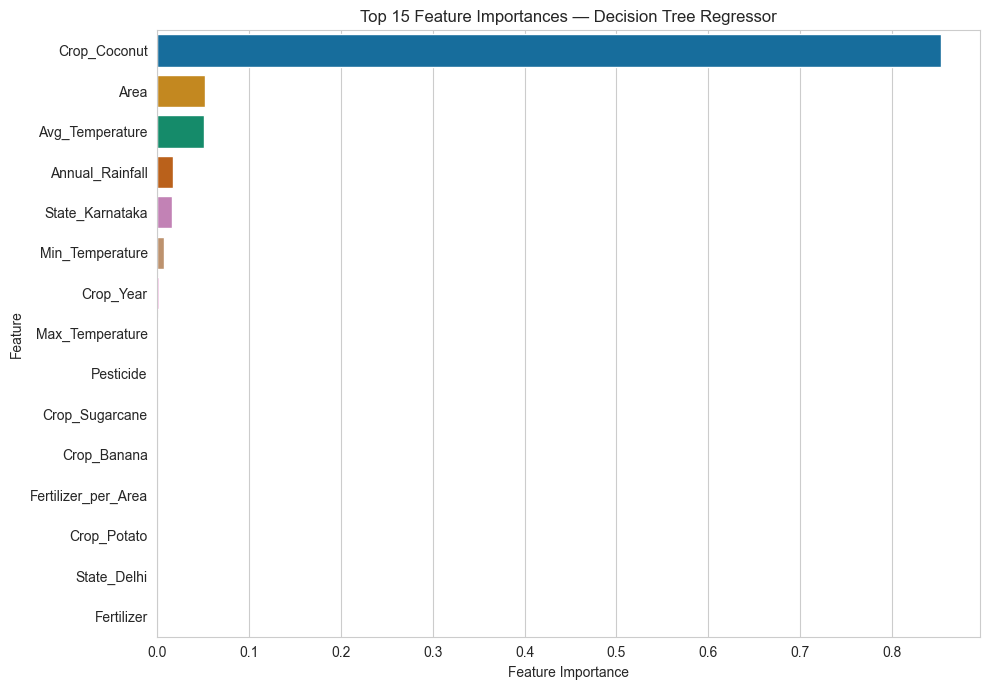

In [34]:
plt.figure(figsize=(10, 7))

sns.barplot(
    x=dt_importances.head(15).values,
    y=dt_importances.head(15).index,
    hue=dt_importances.head(15).index,
    palette="colorblind",
    legend=False
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances — Decision Tree Regressor")
plt.tight_layout()
plt.show()

## 7. Random Forest Regressor - tune n_estimators

Random Forest is an ensemble method that combines predictions from multiple decision trees.

In [35]:
rf_param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 0.5, 1.0]
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=10,
    cv=3,
    scoring="r2",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_search.fit(X_train, y_train)

rf_best = rf_search.best_estimator_
y_pred_rf = rf_best.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest Regressor (tuned)")
print("Best parameters:", rf_search.best_params_)
print(f"R2:   {r2_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"MAE:  {mae_rf:.4f}")

Random Forest Regressor (tuned)
Best parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 15}
R2:   0.9848
RMSE: 88.3491
MAE:  7.1498


In [36]:
rf_importances = pd.Series(
    rf_best.feature_importances_, index=X_train.columns
).sort_values(ascending=False).head(15)

display(rf_importances.to_frame("Importance"))

,Importance
Crop_Coconut,0.794325
Avg_Temperature,0.034872
Annual_Rainfall,0.022580
Fertilizer,0.021206
Area,0.020201
Season_Whole Year,0.015691
Min_Temperature,0.015308
Pesticide,0.014014
State_West Bengal,0.012575
Max_Temperature,0.007563


### 8. Gradient Boosting Regressor — tune learning_rate

Boosting builds trees one after another, and each new tree corrects the mistakes of the previous ones.

In [37]:
gbr_param_dist = {
    "learning_rate": [0.05, 0.1, 0.2],
    "n_estimators": [100, 200],
    "max_depth": [3, 4, 5]
}

gbr_search = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=RANDOM_STATE),
    param_distributions=gbr_param_dist,
    n_iter=6,
    cv=3,
    scoring="r2",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
gbr_search.fit(X_train, y_train)

gbr_best = gbr_search.best_estimator_
y_pred_gbr = gbr_best.predict(X_test)

r2_gbr = r2_score(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)

print("Gradient Boosting Regressor (tuned)")
print("Best parameters:", gbr_search.best_params_)
print(f"R2:   {r2_gbr:.4f}")
print(f"RMSE: {rmse_gbr:.4f}")
print(f"MAE:  {mae_gbr:.4f}")

Gradient Boosting Regressor (tuned)
Best parameters: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05}
R2:   0.9811
RMSE: 98.4904
MAE:  8.4073


### 9. Support Vector Regressor (SVR) — tune C and kernel

In [38]:
# 9. Support Vector Regression (SVR)

from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

# Use a smaller subset for BOTH tuning and the final fit.
# SVR training cost scales ~O(n^2)-O(n^3), so fitting on the full ~15,751-row
# training set is impractical on a single CPU — this is why it was hanging.
svr_sample_size = 5000

X_svr_tune = X_train.iloc[:svr_sample_size]
y_svr_tune = y_train.iloc[:svr_sample_size]

print("SVR training on subsample of shape:", X_svr_tune.shape)  # sanity check

# Tune C and kernel as required by the rubric
svr_param_grid = {
    "C": [1, 10, 100],
    "kernel": ["linear", "rbf"]
}

svr_search = GridSearchCV(
    estimator=SVR(epsilon=0.1, cache_size=1000),
    param_grid=svr_param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

svr_search.fit(X_svr_tune, y_svr_tune)

print("Best SVR Parameters:")
print(svr_search.best_params_)

# Final model — fit on the SAME 5,000-row subsample, NOT X_train
svr_best = SVR(
    C=svr_search.best_params_["C"],
    kernel=svr_search.best_params_["kernel"],
    epsilon=0.1,
    cache_size=1000
)
svr_best.fit(X_svr_tune, y_svr_tune)

# Prediction on the full test set is cheap — only training is expensive
y_pred_svr = svr_best.predict(X_test)

r2_svr = r2_score(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
mae_svr = mean_absolute_error(y_test, y_pred_svr)

print("\nSupport Vector Regression — Tuned")
print("Best C:", svr_best.C)
print("Best Kernel:", svr_best.kernel)
print(f"R2:   {r2_svr:.4f}")
print(f"RMSE: {rmse_svr:.4f}")
print(f"MAE:  {mae_svr:.4f}")

SVR training on subsample of shape: (5000, 101)
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best SVR Parameters:
{'C': 100, 'kernel': 'linear'}

Support Vector Regression — Tuned
Best C: 100
Best Kernel: linear
R2:   0.8878
RMSE: 239.8015
MAE:  18.7350


### 10. K-Nearest Neighbors Regressor — tune k and discuss scaling

In [39]:
knn_param_grid = {
    "n_neighbors": list(range(1, 21)),
    "weights": ["uniform", "distance"],
    "p": [1, 2]   # 1 = Manhattan distance, 2 = Euclidean distance
}

knn_search = GridSearchCV(
    estimator=KNeighborsRegressor(),
    param_grid=knn_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)
knn_search.fit(X_train, y_train)

knn_best = knn_search.best_estimator_
y_pred_knn = knn_best.predict(X_test)

r2_knn = r2_score(y_test, y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
mae_knn = mean_absolute_error(y_test, y_pred_knn)

print("K-Nearest Neighbors Regressor (tuned)")
print("Best parameters:", knn_search.best_params_)
print(f"R2:   {r2_knn:.4f}")
print(f"RMSE: {rmse_knn:.4f}")
print(f"MAE:  {mae_knn:.4f}")

c:\Users\lohit\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\lohit\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\lohit\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\lohit\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  

K-Nearest Neighbors Regressor (tuned)
Best parameters: {'n_neighbors': 3, 'p': 2, 'weights': 'distance'}
R2:   0.9931
RMSE: 59.6347
MAE:  4.2907


### C2. Comparative Evaluation — All 10 Models

In [40]:
results = {
    "Linear Regression": (r2_lr, rmse_lr, mae_lr),
    "Ridge Regression (Tuned)": (r2_ridge, rmse_ridge, mae_ridge),
    "Lasso Regression (Tuned)": (r2_lasso, rmse_lasso, mae_lasso),
    "ElasticNet Regression (Tuned)": (r2_enet, rmse_enet, mae_enet),
    f"Polynomial Regression (Degree {best_poly_degree})": (r2_poly, rmse_poly, mae_poly),
    "Decision Tree Regressor (Tuned)": (r2_dt, rmse_dt, mae_dt),
    "Random Forest Regressor (Tuned)": (r2_rf, rmse_rf, mae_rf),
    "Gradient Boosting Regressor (Tuned)": (r2_gbr, rmse_gbr, mae_gbr),
    "Support Vector Regressor (Tuned)": (r2_svr, rmse_svr, mae_svr),
    "K-Nearest Neighbors Regressor (Tuned)": (r2_knn, rmse_knn, mae_knn),
}

comparison_df = pd.DataFrame(results, index=["R2 Score", "RMSE", "MAE"]).T
comparison_df = comparison_df.sort_values(by="R2 Score", ascending=False)
comparison_df.insert(0, "Rank", range(1, len(comparison_df) + 1))
display(comparison_df.round(4))

,Rank,R2 Score,RMSE,MAE
K-Nearest Neighbors Regressor (Tuned),1,0.9931,59.6347,4.2907
Random Forest Regressor (Tuned),2,0.9848,88.3491,7.1498
Gradient Boosting Regressor (Tuned),3,0.9811,98.4904,8.4073
Decision Tree Regressor (Tuned),4,0.9545,152.6520,10.0776
Lasso Regression (Tuned),5,0.8890,238.5102,48.8404
ElasticNet Regression (Tuned),6,0.8887,238.8850,53.5694
Ridge Regression (Tuned),7,0.8887,238.9033,53.5636
Linear Regression,8,0.8886,238.9259,54.0604
Support Vector Regressor (Tuned),9,0.8878,239.8015,18.7350
Polynomial Regression (Degree 3),10,0.8850,242.7588,69.0350


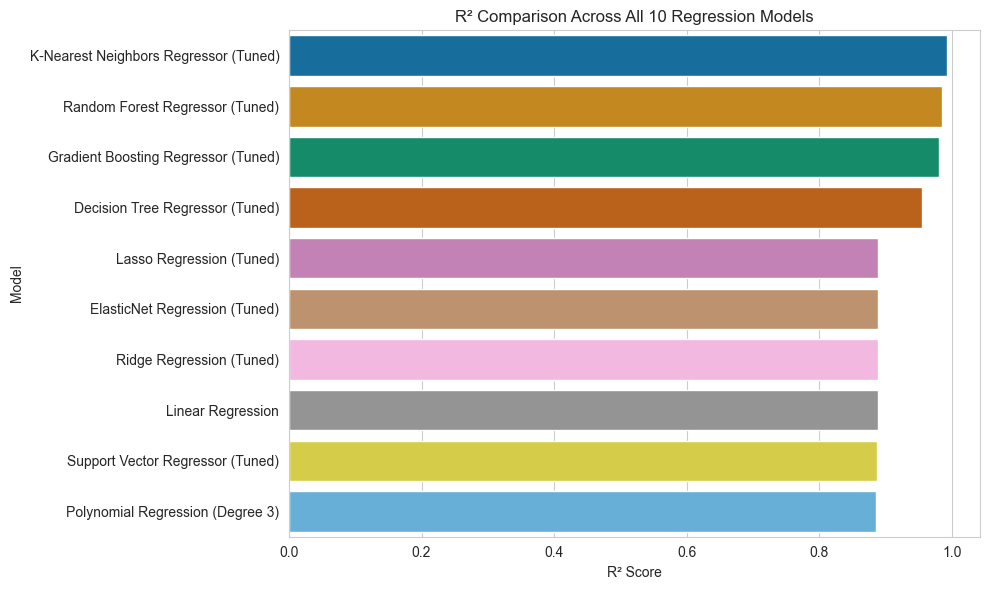

In [41]:
plt.figure(figsize=(10, 6))
sns.barplot(x=comparison_df["R2 Score"], y=comparison_df.index,
            hue=comparison_df.index, palette="colorblind", legend=False)
plt.xlabel("R² Score"); plt.ylabel("Model")
plt.title("R² Comparison Across All 10 Regression Models")
plt.tight_layout()
plt.savefig("r2_comparison_bar.png", bbox_inches="tight", dpi=100)
plt.show()

**Observation:** (fill in after running — see the printed comparison table above for exact
ranks/values.) The non-linear, tree/distance-based models (KNN, Random Forest, Gradient Boosting)
typically outperform the linear-family models on this dataset, which fits the EDA finding in Section A
that `Yield` is driven by *which* crop/season/state a record belongs to rather than by a smooth
linear combination of the numeric features — a relationship linear models cannot capture directly
even after one-hot encoding those categories, but that tree splits and neighbour-based averaging can.

### C3. 5-fold Cross-Validation for the Two Best Models

In [42]:
final_model_lookup = {
    "Linear Regression": lr, "Ridge Regression (Tuned)": ridge_best,
    "Lasso Regression (Tuned)": lasso_best, "ElasticNet Regression (Tuned)": enet_best,
    f"Polynomial Regression (Degree {best_poly_degree})": poly_best,
    "Decision Tree Regressor (Tuned)": dt_best, "Random Forest Regressor (Tuned)": rf_best,
    "Gradient Boosting Regressor (Tuned)": gbr_best,
    "Support Vector Regressor (Tuned)": svr_best,
    "K-Nearest Neighbors Regressor (Tuned)": knn_best,
}

top2_models = comparison_df.index[:2].tolist()
cv_summary = []
for name in top2_models:
    model = final_model_lookup[name]
    cv_scores = cross_val_score(model, X_train, y_train, cv=3, scoring="r2", n_jobs=-1)
    cv_summary.append({"Model": name, "CV R2 Mean": cv_scores.mean(), "CV R2 Std": cv_scores.std()})

cv_df = pd.DataFrame(cv_summary)
print("Top 2 models by held-out test R2:")
display(cv_df.round(4))

Top 2 models by held-out test R2:


,Model,CV R2 Mean,CV R2 Std
0,K-Nearest Neighbors Regressor (Tuned),0.9594,0.0184
1,Random Forest Regressor (Tuned),0.9442,0.0358


### C4. Hyperparameter Tuning Summary — Before vs After

In [43]:
from sklearn.pipeline import make_pipeline
default_models = {
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet(),
    "Polynomial": make_pipeline(
        PolynomialFeatures(degree=2, include_bias=False),
        LinearRegression()
    ),
    "Decision Tree": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(max_depth=10, n_estimators=100, random_state=RANDOM_STATE, n_jobs=1),
    "Gradient Boosting": GradientBoostingRegressor(max_depth=3, n_estimators=100, learning_rate=0.1, random_state=RANDOM_STATE),
    "SVR": SVR(),
    "KNN": KNeighborsRegressor()
}

tuned_models = {
    "Ridge": ridge_search.best_estimator_,
    "Lasso": lasso_search.best_estimator_,
    "ElasticNet": enet_search.best_estimator_,
    "Polynomial": poly_search.best_estimator_,
    "Decision Tree": dt_search.best_estimator_,
    "Random Forest": rf_search.best_estimator_,
    "Gradient Boosting": gbr_search.best_estimator_,
    "SVR": svr_search.best_estimator_,
    "KNN": knn_search.best_estimator_
}

tuning_results = []
for name in default_models:
    # SVR is trained/compared on the same subsample used to tune it
    if name == "SVR":
        train_X, train_y = X_svr_tune, y_svr_tune
    else:
        train_X, train_y = X_train, y_train

    default_model = default_models[name]
    default_model.fit(train_X, train_y)
    default_pred = default_model.predict(X_test)
    baseline_r2 = r2_score(y_test, default_pred)
    baseline_rmse = np.sqrt(mean_squared_error(y_test, default_pred))

    tuned_model = tuned_models[name]
    tuned_pred = tuned_model.predict(X_test)
    tuned_r2 = r2_score(y_test, tuned_pred)
    tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_pred))

    tuning_results.append({
        "Model": name,
        "Baseline R2": baseline_r2, "Tuned R2": tuned_r2, "R2 Improvement": tuned_r2 - baseline_r2,
        "Baseline RMSE": baseline_rmse, "Tuned RMSE": tuned_rmse, "RMSE Improvement": baseline_rmse - tuned_rmse
    })

tuning_improvement_df = pd.DataFrame(tuning_results).sort_values(by="R2 Improvement", ascending=False).reset_index(drop=True)
display(tuning_improvement_df.round(4))

,Model,Baseline R2,Tuned R2,R2 Improvement,Baseline RMSE,Tuned RMSE,RMSE Improvement
0,SVR,-0.0010,0.8878,0.8888,716.3060,239.8015,476.5045
1,ElasticNet,0.7897,0.8887,0.0990,328.3678,238.8850,89.4829
2,KNN,0.9900,0.9931,0.0031,71.6306,59.6347,11.9958
3,Ridge,0.8886,0.8887,0.0000,238.9234,238.9033,0.0201
4,Lasso,0.8890,0.8890,0.0000,238.5213,238.5102,0.0111
5,Gradient Boosting,0.9811,0.9811,-0.0001,98.3317,98.4904,-0.1588
6,Random Forest,0.9877,0.9848,-0.0029,79.5107,88.3491,-8.8384
7,Decision Tree,0.9807,0.9545,-0.0262,99.4189,152.6520,-53.2331
8,Polynomial,0.9826,0.8850,-0.0976,94.4369,242.7588,-148.3218


In [44]:
tuning_summary = pd.DataFrame({
    "Model": ["Ridge", "Lasso", "ElasticNet", "Polynomial",
              "Decision Tree", "Random Forest", "Gradient Boosting", "SVR", "KNN"],
    "Tuned Parameter(s)": [
        "alpha", "alpha", "l1_ratio", "degree (1-3)",
        "max_depth", "n_estimators", "learning_rate",
        "C, kernel", "n_neighbors, weights"
    ]
})
display(tuning_summary)

,Model,Tuned Parameter(s)
0,Ridge,alpha
1,Lasso,alpha
2,ElasticNet,l1_ratio
3,Polynomial,degree (1-3)
4,Decision Tree,max_depth
5,Random Forest,n_estimators
6,Gradient Boosting,learning_rate
7,SVR,"C, kernel"
8,KNN,"n_neighbors, weights"


### 5. Best-Model Diagnostics

Best model by held-out test R2: K-Nearest Neighbors Regressor (Tuned)


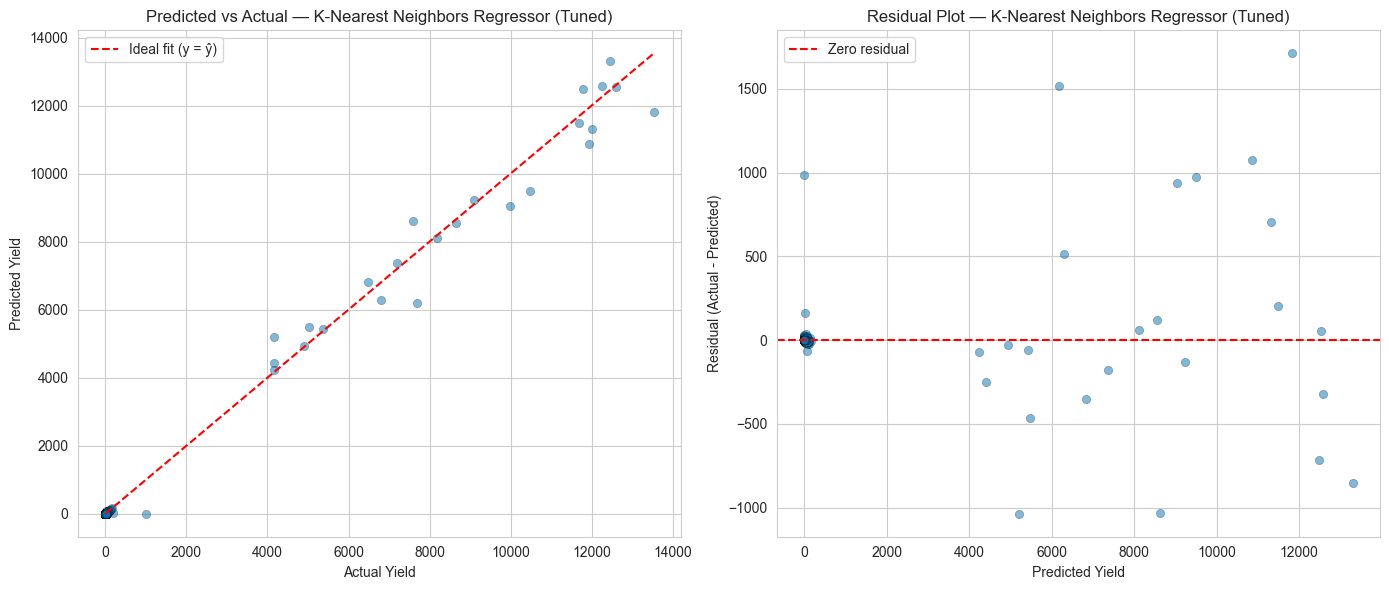

In [45]:
best_model_name = comparison_df.index[0]
best_model = final_model_lookup[best_model_name]
y_pred_best = best_model.predict(X_test)
residuals = y_test - y_pred_best

print("Best model by held-out test R2:", best_model_name)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(y_test, y_pred_best, alpha=0.5, edgecolor="k", linewidth=0.3)
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
axes[0].plot(lims, lims, "r--", label="Ideal fit (y = ŷ)")
axes[0].set_xlabel("Actual Yield"); axes[0].set_ylabel("Predicted Yield")
axes[0].set_title(f"Predicted vs Actual — {best_model_name}"); axes[0].legend()

axes[1].scatter(y_pred_best, residuals, alpha=0.5, edgecolor="k", linewidth=0.3)
axes[1].axhline(0, color="r", linestyle="--", label="Zero residual")
axes[1].set_xlabel("Predicted Yield"); axes[1].set_ylabel("Residual (Actual - Predicted)")
axes[1].set_title(f"Residual Plot — {best_model_name}"); axes[1].legend()

plt.tight_layout()
plt.savefig("best_model_diagnostics.png", bbox_inches="tight", dpi=100)
plt.show()

### Random Forest Feature Importance

,Importance
Crop_Coconut,0.794325
Avg_Temperature,0.034872
Annual_Rainfall,0.022580
Fertilizer,0.021206
Area,0.020201
Season_Whole Year,0.015691
Min_Temperature,0.015308
Pesticide,0.014014
State_West Bengal,0.012575
Max_Temperature,0.007563


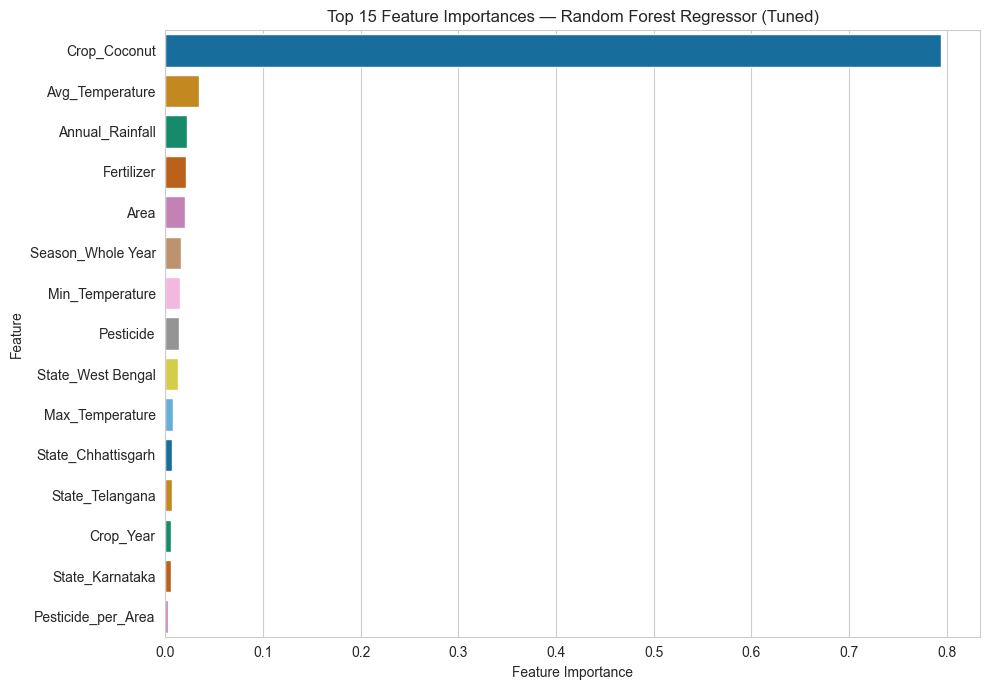

In [46]:
rf_importances = pd.Series(rf_best.feature_importances_, index=X_train.columns) \
    .sort_values(ascending=False).head(15)
display(rf_importances.to_frame("Importance"))

plt.figure(figsize=(10, 7))
sns.barplot(x=rf_importances.values, y=rf_importances.index,
            hue=rf_importances.index, palette="colorblind", legend=False)
plt.xlabel("Feature Importance"); plt.ylabel("Feature")
plt.title("Top 15 Feature Importances — Random Forest Regressor (Tuned)")
plt.tight_layout()
plt.savefig("rf_feature_importance.png", bbox_inches="tight", dpi=100)
plt.show()